# The index method, explained from zero

**Read [`00-concepts.ipynb`](00-concepts.ipynb) first.** That notebook builds
every term used here — cycle, engine, bundle, latency, scratchpad, footprint —
and ends at §12 by naming what this notebook explains.

**Source of truth.** Every rule, every figure and every number below is produced
by running the solution modules, never by retyping what they do. The compiler
being explained is already written; this notebook imports it and calls it. If a
module changed, these cells would disagree with the prose and you would see it.

**How to run this.** Pick the same kernel as notebook 00, then run the cells in
order, top to bottom. Nothing here writes to the repository and nothing touches
the pinned reference.

---

## 0. Setup

Four directories of code matter, and they are layered. `machine` is the frozen
hardware model. `direct_contract` derives facts from a program. `schema_index`
owns the representation this whole notebook is about. `direct_constraints`,
`direct_compiler` and `direct_optimizer` build on it.

In [1]:
import json
import math
import sys
from pathlib import Path

ROOT = Path("/Users/alberto/Documents/projects/CausalBool/luminal-challenge").resolve()
for entry in (str(ROOT / ".reference"), str(ROOT), str(ROOT / "notebooks")):
    if entry not in sys.path:
        sys.path.insert(0, entry)

import machine              # the frozen machine model and validator (do not modify)
import compiler             # the starter compiler, used here only as a baseline

import direct_contract as dc        # derived program facts
import schema_index as si           # THE representation: cubes, fields, solve
import direct_constraints as dk     # covers of relations, and the joint query
import direct_compiler as dcomp     # the bootstrap: schedule and allocate
import direct_optimizer as dopt     # bounded joint improvement

import viz                  # every figure in this notebook and in notebook 00

for name, module in (("machine", machine), ("schema_index", si),
                     ("direct_constraints", dk), ("direct_compiler", dcomp),
                     ("direct_optimizer", dopt), ("viz", viz)):
    print(f"{name:20} {Path(module.__file__).relative_to(ROOT)}")

machine              .reference/machine.py
schema_index         schema_index.py
direct_constraints   direct_constraints.py
direct_compiler      direct_compiler.py
direct_optimizer     direct_optimizer.py
viz                  notebooks/viz.py


---

# 1. The question, and two ways to answer it

Notebook 00 reduced the whole exercise to two questions, asked once per
operation and once per value:

| Question | The name for answering it |
|---|---|
| **When** does this operation issue? | scheduling |
| **Where** does this result live? | allocation |

The conventional answer is a **greedy list scheduler**. It keeps a queue of
operations whose inputs are ready, sorts that queue by some priority — usually
distance to the end of the dependency chain — and pops from it until the
cycle's engine slots are full. Allocation then scans the live intervals and
hands each value the first free address. Both steps are *rules*: do this, then
this, and take what the rule gives you.

The method in this repository answers the same two questions differently. It
never applies a rule. For each decision it **states the set of legal answers as
an object, and then asks that object for a member**:

> A greedy scheduler asks *"what does my priority rule pick?"*
> This method asks *"what is the set of cycles that are still legal, and what is
> the smallest thing in it?"*

The rest of this notebook is about what that set is, how it is written down so
that it stays small, and what it costs.

One thing to fix in your mind before starting, because it is the source of most
confusion: **the set is never listed**. It is represented. The representation is
the subject of §2.

In [2]:
program = machine.load_program(ROOT / ".reference/programs/02_scalar_dual_chain.json")

starter = compiler.compile_program(program)
direct, report = dcomp.compile_with_report(program)

for label, compiled in (("starter (baseline)", starter), ("index method", direct)):
    cycles = machine.check_compilation(program, compiled)
    for case in program["cases"]:
        machine.check_case(program, compiled, case)          # raises if wrong
    words = machine.scratch_footprint(program, compiled)
    print(f"{label:20} {cycles:>3} cycles  {words:>3} words  product {cycles * words:>4}")

print()
print(f"both answers were accepted by the frozen validator on all "
      f"{len(program['cases'])} test cases")

starter (baseline)    12 cycles    9 words  product  108
index method           8 cycles    3 words  product   24

both answers were accepted by the frozen validator on all 2 test cases


Same program, same machine, same validator. The second answer is smaller, and
every decision inside it was retrieved from a set rather than chosen by a rule.

---

# 2. The cube: the one object

Everything rests on a single data structure. It is worth meeting it before any
compiler question is asked of it.

A **cube** is two integers:

- an **anchor** — a number, and
- a **free mask** — which bit positions are allowed to vary.

Together they denote a *set of integers*: take the anchor, and add any subset of
the weights of the free coordinates. Coordinates are LSB-first, so coordinate
`i` carries weight `2**i`. Those additions are the cube's **sumandos**.

That is the entire definition. Let us build one.

In [3]:
cube = si.Cube(n=4, anchor=0b0010, free_mask=0b1001)

print("n          :", cube.n, "  (a 4 bit universe, so indices 0..15)")
print("anchor     :", cube.anchor, "=", format(cube.anchor, "04b"), "(read MSB-first here)")
print("free_mask  :", cube.free_mask, "=", format(cube.free_mask, "04b"))
print("fixed_mask :", cube.fixed_mask, "=", format(cube.fixed_mask, "04b"))
print()
print("label      :", cube.label(), "   <- LSB-first: x0 is leftmost, * means free")
print("size       :", cube.size, "  (= 2 ** number of free coordinates)")
print("members    :", list(cube.members()))

n          : 4   (a 4 bit universe, so indices 0..15)
anchor     : 2 = 0010 (read MSB-first here)
free_mask  : 9 = 1001
fixed_mask : 6 = 0110

label      : x0..x3:*10*    <- LSB-first: x0 is leftmost, * means free
size       : 4   (= 2 ** number of free coordinates)
members    : [2, 3, 10, 11]


Read the label `x0..x3:*10*` left to right as coordinates x0, x1, x2, x3:

| coordinate | x0 | x1 | x2 | x3 |
|---|---|---|---|---|
| weight | 1 | 2 | 4 | 8 |
| this cube | `*` free | `1` fixed | `0` fixed | `*` free |

So x1 must be 1 (contributing 2) and x2 must be 0 (contributing 0), while x0 and
x3 are free to be anything. The anchor is 2, and the sumandos are the four
subsets of {1, 8}: 0, 1, 8, 9. Adding those to the anchor gives **2, 3, 10, 11**
— exactly the members printed above.

Two integers just denoted a four-element set without storing four elements. That
is the whole trick, and the next cell shows what it buys.

In [4]:
# Turn the knob: free one more coordinate and the set doubles, the object does not.
print(f"{'free coordinates':>18}  {'label':<16} {'size':>6}  members")
for free in (0b0000, 0b1000, 0b1001, 0b1011, 0b1111):
    grown = si.Cube(4, anchor=0b0010 & ~free, free_mask=free)
    listed = list(grown.members())
    shown = listed if len(listed) <= 8 else listed[:8] + ["..."]
    print(f"{grown.free_mask.bit_count():>18}  {grown.label():<16} {grown.size:>6}  {shown}")

print()
print("the object is always the same two integers, whatever the set size")

  free coordinates  label              size  members
                 0  x0..x3:0100           1  [2]
                 1  x0..x3:010*           2  [2, 10]
                 2  x0..x3:*10*           4  [2, 3, 10, 11]
                 3  x0..x3:**0*           8  [0, 1, 2, 3, 8, 9, 10, 11]
                 4  x0..x3:****          16  [0, 1, 2, 3, 4, 5, 6, 7, '...']

the object is always the same two integers, whatever the set size


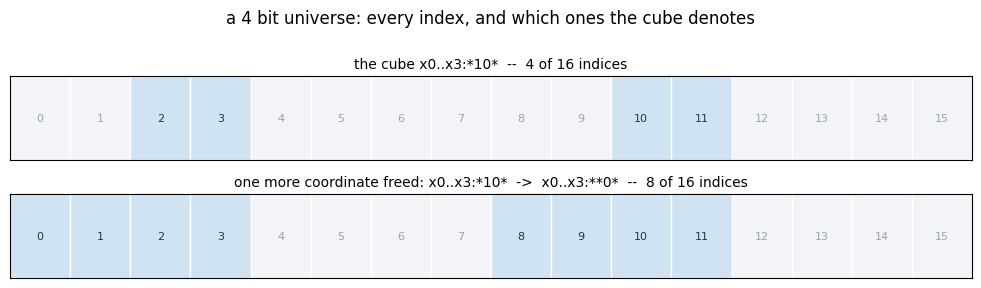

In [5]:
viz.show_universe(
    [("the cube x0..x3:*10*", (cube,)),
     ("one more coordinate freed: x0..x3:*10*  ->  x0..x3:**0*", (si.Cube(4, 0b0000, 0b1011),))],
    n=4,
    title="a 4 bit universe: every index, and which ones the cube denotes",
)

---

# 3. The algebra: answering questions by intersecting

A single cube is a set. The method needs to *combine* sets — "legal for this
reason **and** legal for that reason", "legal **except** where something else
already sits". `schema_index` provides exactly those operations, and each one
returns cubes again, so the representation never degrades into a list.

## 3.1 Intersection

Two cubes meet where their fixed coordinates agree. The result is one cube:
anchors combined, free masks intersected. It is computed with three integer
operations and no enumeration at all.

In [6]:
a = si.Cube(4, anchor=0b0010, free_mask=0b1001)   # x0..x3:*10*
b = si.Cube(4, anchor=0b0000, free_mask=0b0011)   # x0..x3:**00

met = si.intersect(a, b)

print(f"a       {a.label()}   {sorted(a.members())}")
print(f"b       {b.label()}   {sorted(b.members())}")
print(f"a & b   {met.label()}   {sorted(met.members())}")
print()

# The claim is exactness, so check it against ordinary Python sets.
expected = set(a.members()) & set(b.members())
print("plain Python set intersection:", sorted(expected))
print("cube algebra agrees          :", set(met.members()) == expected)

a       x0..x3:*10*   [2, 3, 10, 11]
b       x0..x3:**00   [0, 1, 2, 3]
a & b   x0..x3:*100   [2, 3]

plain Python set intersection: [2, 3]
cube algebra agrees          : True


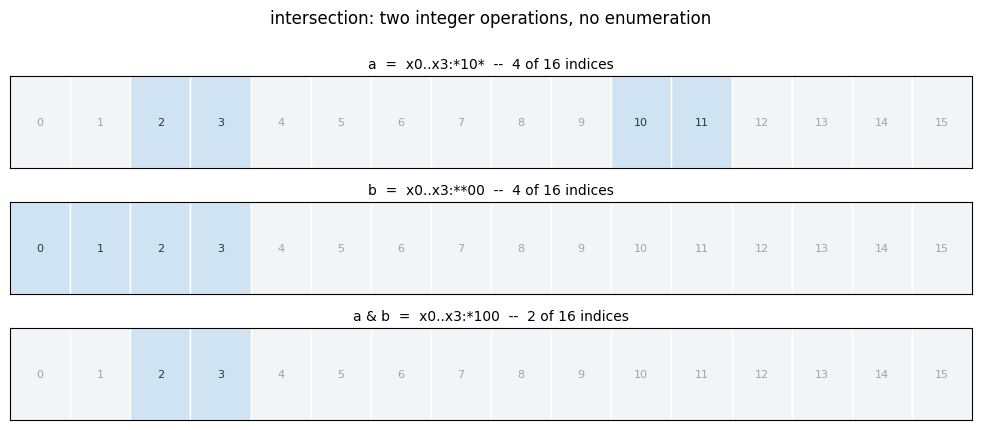

In [7]:
viz.show_universe(
    [("a  =  " + a.label(), (a,)),
     ("b  =  " + b.label(), (b,)),
     ("a & b  =  " + met.label(), (met,))],
    n=4,
    title="intersection: two integer operations, no enumeration",
)

## 3.2 Difference

Subtraction is the operation that makes "everything except what is already
taken" expressible. It cannot return a single cube in general — removing a
middle slice from a block leaves two pieces — so it returns a **disjoint
cover**: several cubes whose union is exactly the answer, with no overlaps.

This is the operation that answers *"which cycles are still free?"* in §5 and
*"which addresses are still free?"* in §6.

In [8]:
removed = si.difference(a, b)

print(f"a         {a.label()}      {sorted(a.members())}")
print(f"b         {b.label()}      {sorted(b.members())}")
print(f"a - b     {len(removed)} cube(s): {[c.label() for c in removed]}")

union = set()
for piece in removed:
    union |= set(piece.members())
expected = set(a.members()) - set(b.members())
print()
print("plain Python set difference:", sorted(expected))
print("cover denotes              :", sorted(union))
print(f"agrees over {len(expected)} element(s):", union == expected)

# Disjointness is what keeps a cover from growing without bound.
total = sum(piece.size for piece in removed)
print(f"pieces are disjoint        : {total} == {len(union)} -> {total == len(union)}")

a         x0..x3:*10*      [2, 3, 10, 11]
b         x0..x3:**00      [0, 1, 2, 3]
a - b     1 cube(s): ['x0..x3:*101']

plain Python set difference: [10, 11]
cover denotes              : [10, 11]
agrees over 2 element(s): True
pieces are disjoint        : 2 == 2 -> True


---

# 4. Fields: one index carries several decisions

So far a cube denotes a set of plain integers. A compiler decision is not a
plain integer — it is *"operation 2 issues at cycle 1"*, or *"value `y1` lives at
address 0"*.

A **field** is a named, contiguous slice of bit positions inside the index. It
turns one integer into a record of several decisions, each readable on its own.
Everything outside a field is left free, so a constraint on one decision says
nothing about the others.

In [9]:
cycle_field = si.Field(name="t", offset=0, width=4)

print("field      :", cycle_field.name, "| offset", cycle_field.offset,
      "| width", cycle_field.width)
print("mask       :", format(cycle_field.mask, "04b"))
print("holds      : values 0 ..", cycle_field.limit - 1)
print()
print("encode(6)  :", cycle_field.encode(6), "=", format(cycle_field.encode(6), "04b"))
print("decode(6)  :", cycle_field.decode(6))

field      : t | offset 0 | width 4
mask       : 1111
holds      : values 0 .. 15

encode(6)  : 6 = 0110
decode(6)  : 6


## 4.1 A range is a handful of cubes, not a list of values

Here is the operation the scheduler leans on. "The cycle must lie between 3 and
11 inclusive" is a set of nine values. `si.interval` returns it as an exact,
disjoint cover of **aligned binary blocks** — and there are three of them, not
nine.

In [10]:
cover = si.interval(cycle_field, lo=3, hi=11, n=4)

print(f"3 <= t <= 11  ->  {len(cover)} cubes for 9 values")
for piece in cover:
    print(f"   {piece.label()}   denotes {sorted(piece.members())}")

union = set()
for piece in cover:
    union |= set(piece.members())
print()
print("union:", sorted(union), " exact:", union == set(range(3, 12)))

3 <= t <= 11  ->  3 cubes for 9 values
   x0..x3:1100   denotes [3]
   x0..x3:**10   denotes [4, 5, 6, 7]
   x0..x3:**01   denotes [8, 9, 10, 11]

union: [3, 4, 5, 6, 7, 8, 9, 10, 11]  exact: True


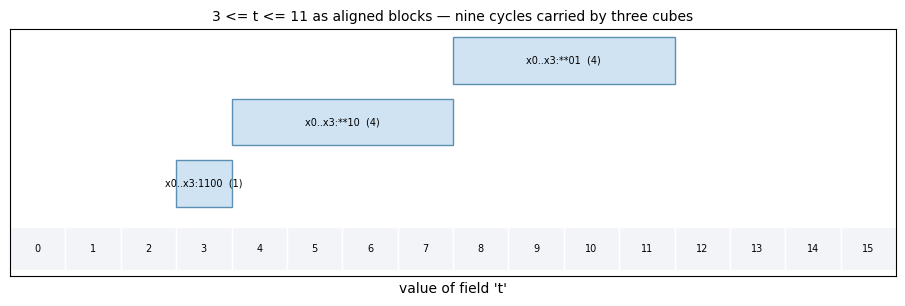

In [11]:
viz.show_cover_blocks(
    cover, cycle_field, lo=0, hi=15,
    title="3 <= t <= 11 as aligned blocks — nine cycles carried by three cubes",
)

## 4.2 How the cover size actually grows

If a range of nine values costs three cubes, what does a range of a thousand
cost? The answer is what makes the method viable: the cover grows with the
**number of bits**, not with the number of values.

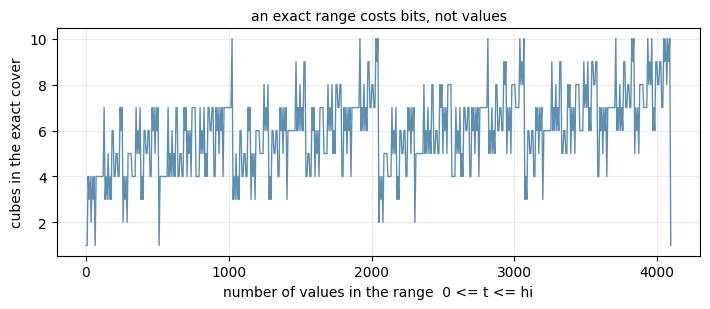

widest range here: 4,096 values -> at most 10 cubes
listing them would have cost 4,096 integers


In [12]:
import matplotlib.pyplot as plt

wide = si.Field("t", 0, 12)
widths, sizes = [], []
for hi in range(0, 1 << 12, 7):
    widths.append(hi + 1)
    sizes.append(len(si.interval(wide, 0, hi, 12)))

fig, ax = plt.subplots(figsize=(7.2, 3.2))
ax.plot(widths, sizes, linewidth=1.0, color=viz.EDGE)
ax.set_xlabel("number of values in the range  0 <= t <= hi")
ax.set_ylabel("cubes in the exact cover")
ax.set_title("an exact range costs bits, not values", fontsize=10)
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

print(f"widest range here: {max(widths):,} values -> at most {max(sizes)} cubes")
print(f"listing them would have cost {max(widths):,} integers")

---

# 5. Scheduling, as a query

Now the first real compiler question. We use `02_scalar_dual_chain.json`, the
same program notebook 00 used in §2, so the shapes are already familiar.

In [13]:
facts = dc.derive(program)

print(f"operations {facts.count}   values {len(facts.value_names)}   horizon {facts.horizon}")
print(f"time field width: {dc.time_width(facts.horizon)} bits\n")
print(f"{'op':>3}  {'opcode':8} {'engine':8} {'slots':>5} {'latency':>7}  produces")
for op_id in range(facts.count):
    engine = facts.engine[op_id]
    print(f"{op_id:>3}  {facts.opcode[op_id]:8} {engine:8} "
          f"{machine.ENGINE_LIMITS[engine]:>5} {facts.latency[op_id]:>7}  "
          f"{facts.dest[op_id] or '-'}")

operations 11   values 9   horizon 21
time field width: 5 bits

 op  opcode   engine   slots latency  produces
  0  load     load         2       3  a0
  1  load     load         2       3  b0
  2  load     load         2       3  c0
  3  load     load         2       3  d0
  4  mul      scalar       2       2  left_product
  5  mul      scalar       2       2  right_product
  6  add      scalar       2       1  cross
  7  add      scalar       2       1  left
  8  xor      scalar       2       1  right
  9  store    store        1       1  -
 10  store    store        1       1  -


The `load` engine has **two** slots and there are four loads, so two of them
cannot issue in the first cycle. That collision is where a rule and a query
visibly differ, and it happens at operation 2.

Every issue cycle in this compilation is chosen by one function,
`direct_compiler._earliest_cycle`. The cell below wraps it to record what it was
asked, runs a genuine compilation through it, and prints the log. Nothing is
reimplemented — the real function does the work.

In [14]:
log = []
original = dcomp._earliest_cycle

def recording(facts, op_id, lower, full_cycles, field, width, budget, counters):
    blocked = list(full_cycles.get(facts.engine[op_id], []))
    chosen = original(facts, op_id, lower, full_cycles, field, width, budget, counters)
    log.append({"op": op_id, "lower": lower, "blocked": blocked, "chosen": chosen})
    return chosen

dcomp._earliest_cycle = recording
try:
    times, addresses = dcomp.bootstrap(
        facts, dcomp.DEFAULT_LIMITS, dcomp._Deadline(15.0), dcomp._Counters()
    )
finally:
    dcomp._earliest_cycle = original          # always put the real one back

print(f"{'op':>3} {'engine':8} {'earliest by data':>17} {'engine full at':16} {'chosen':>6}")
for entry in log:
    print(f"{entry['op']:>3} {facts.engine[entry['op']]:8} {entry['lower']:>17} "
          f"{str(entry['blocked']):16} {entry['chosen']:>6}")

 op engine    earliest by data engine full at   chosen
  0 load                     0 []                    0
  1 load                     0 []                    0
  2 load                     0 [0]                   1
  3 load                     0 [0]                   1
  4 scalar                   3 []                    3
  5 scalar                   4 []                    4
  6 scalar                   4 []                    4
  7 scalar                   5 [4]                   5
  8 scalar                   6 [4]                   6
  9 store                    6 []                    6
 10 store                    7 [6]                   7


Read the row for **operation 2**. Its data are ready at cycle 0, but cycle 0 is
already full on the `load` engine — operations 0 and 1 took both slots — so it
issues at cycle 1.

A greedy scheduler reaches that answer by a rule: *try the earliest cycle, and if
the slot is taken, try the next one.* The method reaches it by building the set
of legal cycles and taking its smallest member. The next cell does exactly that,
step by step, with the same public operations the real function uses.

In [15]:
op_id, lower, blocked = 2, 0, [0]

width = dc.time_width(facts.horizon)
field = si.Field("t", 0, width)

# The window: from the earliest data-ready cycle to a bound the method proves is
# always reachable. ``prefix_horizon`` is the sum of the latencies before op 2.
hi = min(facts.horizon - 1, max(lower + len(blocked), facts.prefix_horizon(op_id)))
print(f"window for op{op_id}: cycles {lower} .. {hi}   ({hi - lower + 1} cycles)")

meter = si.Budget(seconds=1.0).start()

window = si.interval(field, lower, hi, width)
meter.cover(len(window))
print(f"  step 1  the window as cubes      : {len(window)} -> {[c.label() for c in window]}")

taken = tuple(si.Cube(width, field.encode(c), 0) for c in blocked if c <= hi)
print(f"  step 2  cycles already full      : {[c.label() for c in taken]}")

legal = dcomp._subtract_cover(window, taken, meter)
print(f"  step 3  window minus those       : {len(legal)} -> {[c.label() for c in legal]}")

smallest = si.min_member(legal)
print(f"  step 4  smallest member          : index {smallest} -> cycle {field.decode(smallest)}")

window for op2: cycles 0 .. 6   (7 cycles)
  step 1  the window as cubes      : 3 -> ['x0..x4:**000', 'x0..x4:*0100', 'x0..x4:01100']
  step 2  cycles already full      : ['x0..x4:00000']
  step 3  window minus those       : 4 -> ['x0..x4:1*000', 'x0..x4:01000', 'x0..x4:*0100', 'x0..x4:01100']
  step 4  smallest member          : index 1 -> cycle 1


In [16]:
# What survives, spelled out, and checked against the function that is shipped.
admitted = set()
for piece in legal:
    required = piece.anchor & field.mask
    fixed = piece.fixed_mask & field.mask
    admitted |= {v for v in range(lower, hi + 1)
                 if (field.encode(v) & fixed) == required}

print("cycles still legal:", sorted(admitted))
print(f"denominator       : window held {hi - lower + 1}, 1 removed, {len(admitted)} remain")
print()

shipped = original(facts, op_id, lower, {"load": blocked}, field, width,
                   si.Budget(seconds=1.0), dcomp._Counters())
print(f"the shipped _earliest_cycle returns : {shipped}")
print(f"this cell's set query returns       : {field.decode(smallest)}")
print("agree                               :", shipped == field.decode(smallest))

cycles still legal: [1, 2, 3, 4, 5, 6]
denominator       : window held 7, 1 removed, 6 remain

the shipped _earliest_cycle returns : 1
this cell's set query returns       : 1
agree                               : True


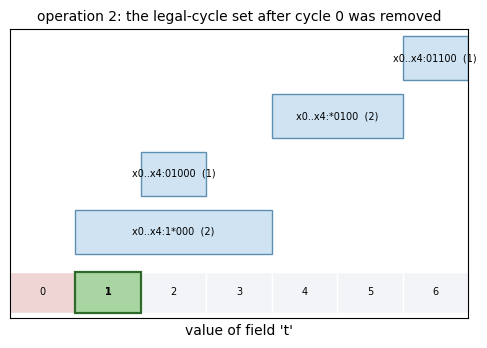

In [17]:
viz.show_cover_blocks(
    legal, field, lo=0, hi=hi,
    title=f"operation {op_id}: the legal-cycle set after cycle 0 was removed",
    excluded=blocked,
    chosen=field.decode(smallest),
)

---

# 6. Allocation, as the same kind of query

Allocation asks *where*, and the machine imposes one extra rule that scheduling
does not have: a vector occupies eight consecutive words and **must start at a
multiple of eight**.

In a conventional allocator that rule is a loop condition — *skip this address if
it is not aligned*. Here it is not a condition at all. It is a cube.

In [18]:
print("VLEN          :", machine.VLEN, " words per vector")
print("SCRATCH_WORDS :", machine.SCRATCH_WORDS)
print("ADDRESS_WIDTH :", dc.ADDRESS_WIDTH, "bits\n")

universe = dc.ADDRESS_WIDTH
alignment = si.Cube(universe, 0, si.universe_mask(universe) ^ (machine.VLEN - 1))

print("the alignment rule, as one cube:", alignment.label())
print("   the three lowest coordinates are fixed to 0; everything above is free")
print("   it denotes", alignment.size, "addresses:",
      [m for _, m in zip(range(6), alignment.members())], "...")
print()
print("every legal vector address, and no others:",
      sorted(alignment.members()) == list(range(0, machine.SCRATCH_WORDS, machine.VLEN)))

VLEN          : 8  words per vector
SCRATCH_WORDS : 256
ADDRESS_WIDTH : 8 bits

the alignment rule, as one cube: x0..x7:000*****
   the three lowest coordinates are fixed to 0; everything above is free
   it denotes 32 addresses: [0, 8, 16, 24, 32, 40] ...

every legal vector address, and no others: True


`x0..x7:000*****` *is* the alignment rule. Intersecting any candidate set with
it leaves exactly the aligned addresses, at the cost of one integer operation.
No address is ever tested and rejected.

Now the whole allocation, on a program with real vectors.

In [19]:
vector_program = machine.load_program(ROOT / ".reference/programs/03_vector_axpy.json")
vector_facts = dc.derive(vector_program)

vector_times, vector_addresses = dcomp.bootstrap(
    vector_facts, dcomp.DEFAULT_LIMITS, dcomp._Deadline(15.0), dcomp._Counters()
)
vector_life = dc.lifetimes(vector_facts, vector_times)

print(f"{'value':12} {'width':>5} {'live cycles':>12} {'address':>8}  {'aligned?':>8}")
for name in vector_facts.value_names:
    w = vector_facts.width[name]
    a = vector_addresses[name]
    mark = "-" if w != machine.VLEN else ("yes" if a % machine.VLEN == 0 else "NO")
    print(f"{name:12} {w:>5} {str(vector_life[name]):>12} {a:>8}  {mark:>8}")

print()
print("footprint:", dc.footprint(vector_facts, vector_addresses), "words")
print("cycles   :", max(vector_times.values()) + 1)

value        width  live cycles  address  aligned?
alpha            1       (1, 1)        0         -
valpha           8       (2, 5)        0       yes
x0               8       (4, 4)        8       yes
y0               8       (5, 7)        8       yes
x1               8       (5, 5)       16       yes
y1               8       (6, 8)        0       yes
scaled0          8       (7, 7)       16       yes
scaled1          8       (8, 8)        8       yes
result0          8       (8, 8)       16       yes
result1          8       (9, 9)        0       yes

footprint: 24 words
cycles   : 10


Notice `alpha` and `valpha` both sitting at address 0. `alpha` is live only at
cycle 1 and `valpha` is written at cycle 2, so the second may take over the
first's space. That reuse was not planned by a heuristic — it is what the
smallest member of the legal-address set happened to be, once the addresses
occupied by *overlapping* values had been subtracted.

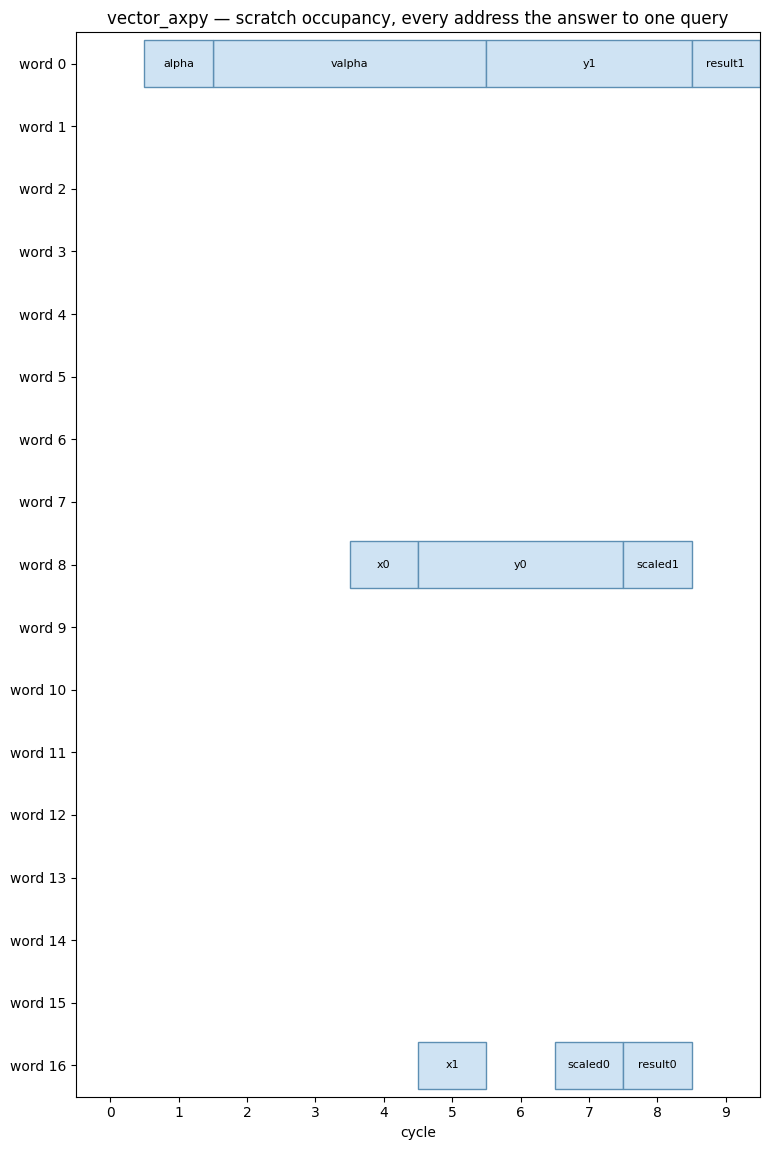

In [20]:
viz.show_lifetimes(
    vector_facts, vector_addresses, vector_life,
    max(vector_times.values()) + 1,
    "vector_axpy — scratch occupancy, every address the answer to one query",
)

---

# 7. The bootstrap, end to end

§5 and §6 together are the whole first solution. The compiler walks the
operations in order, asks one scheduling query each, then walks the values and
asks one allocation query each. Nothing backtracks.

The method must argue that this **always succeeds** — a query that returns an
empty set would be a compilation failure, not a fallback to something else. Both
arguments are stated in the source, at `_earliest_cycle` and `_lowest_address`,
and they are why there is no classical path hiding behind this one.

In [21]:
compiled, report = dcomp.compile_with_report(program)

print("stage      :", report["stage"])
print("cycles     :", report["cycles"], " (lower bound", report["cycle_lower_bound"], ")")
print("footprint  :", report["footprint"], " (lower bound", report["memory_lower_bound"], ")")
print("product    :", report["product"])
print("seconds    :", round(report["seconds"], 3))
print()
print("queries asked        :", report["queries"]["queries"])
print("largest cover seen   :", report["queries"]["largest_cover"], "cubes")
print("cube intersections   :", f"{report['queries']['intersections']:,}")

machine.check_compilation(program, compiled)
for case in program["cases"]:
    machine.check_case(program, compiled, case)
print()
print(f"frozen validator accepted the result on all {len(program['cases'])} cases")

stage      : bootstrap
cycles     : 8  (lower bound 7 )
footprint  : 3  (lower bound 1 )
product    : 24
seconds    : 0.147

queries asked        : 25
largest cover seen   : 4 cubes
cube intersections   : 1,194,264

frozen validator accepted the result on all 2 cases


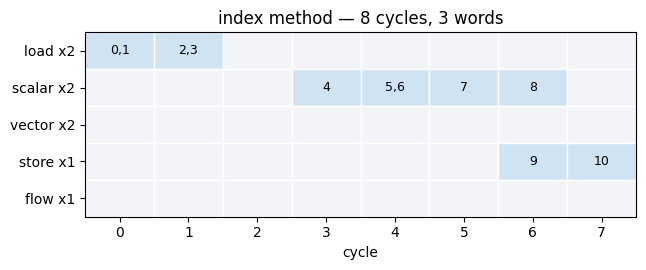

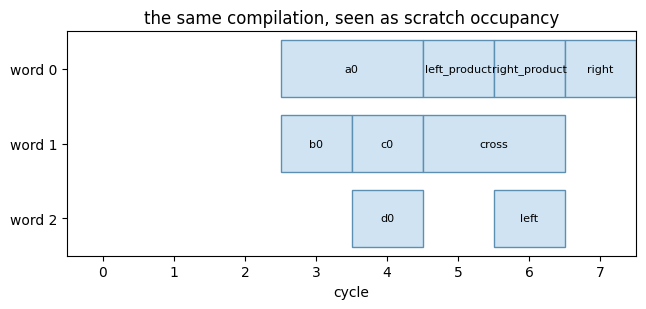

In [22]:
viz.show_timeline(
    compiled["bundles"],
    f"index method — {report['cycles']} cycles, {report['footprint']} words",
)
viz.show_lifetimes(
    facts, compiled["scratch"], dc.lifetimes(facts, times),
    report["cycles"], "the same compilation, seen as scratch occupancy",
)

---

# 8. The joint query: many decisions at once

Everything so far decided **one thing at a time**. That is enough to produce a
correct, compact schedule, but it cannot undo an early choice that turns out to
cost something later.

The optimiser asks a harder question. It picks a small **window** of operations,
declares a **target** — fewer cycles, or a smaller footprint — and asks for
*all* of that window's issue times, result addresses and engine lanes **at
once**, subject to every constraint at the same time.

This is where the representation earns its keep, because the number of
combinations involved is not small.

In [23]:
incumbent_cycles = max(times.values()) + 1
incumbent_memory = dc.footprint(facts, addresses)

print(f"incumbent: {incumbent_cycles} cycles x {incumbent_memory} words "
      f"= product {incumbent_cycles * incumbent_memory}")
print()
print("targets it will try, in order (each must beat the product strictly):")
for target in dopt.targets_for(facts, incumbent_cycles, incumbent_memory):
    print(f"   {target[0]} cycles x {target[1]} words = {target[0] * target[1]}")

windows = dopt.windows_for(facts, times, addresses, scratch_first=True)
print()
print(f"candidate windows ({len(windows)}):", windows[:4], "...")
print("window size:", dopt.WINDOW_SIZE, "operations")

incumbent: 8 cycles x 3 words = product 24

targets it will try, in order (each must beat the product strictly):
   7 cycles x 3 words = 21
   8 cycles x 2 words = 16
   9 cycles x 2 words = 18

candidate windows (8): [(1, 2, 3, 7), (7, 8, 9, 10), (0, 1, 2, 3), (2, 3, 4, 5)] ...
window size: 4 operations


## 8.1 The index is a record of every decision in the window

One integer now has to carry four issue times, four addresses and four lane
bits. Each gets its own field, laid out end to end.

In [24]:
window = windows[0]
target_cycles, target_memory = 8, 2          # a target this window cannot meet

meter = si.Budget(seconds=1.0, max_cover=4096, max_visited=50000,
                  max_records=20000).start()
query = dk.JointQuery(facts, times, addresses, window, target_cycles,
                      target_memory, meter, dk.CoverCache())

print("window          :", window)
print("target          :", (target_cycles, target_memory))
print("index width     :", query.n, "bits")
print()
fields = (list(query.time_field.values()) + list(query.address_field.values())
          + list(query.lane_field.values()))
for f in sorted(fields, key=lambda f: f.offset):
    print(f"   {f.name:10} bits {f.offset:>3}..{f.offset + f.width - 1:<3} "
          f"width {f.width}")

print()
print(f"assignments this index can express: 2**{query.n} = {1 << query.n:,}")

window          : (1, 2, 3, 7)
target          : (8, 2)
index width     : 56 bits

   t1         bits   0..4   width 5
   a_b0       bits   5..12  width 8
   l1         bits  13..13  width 1
   t2         bits  14..18  width 5
   a_c0       bits  19..26  width 8
   l2         bits  27..27  width 1
   t3         bits  28..32  width 5
   a_d0       bits  33..40  width 8
   l3         bits  41..41  width 1
   t7         bits  42..46  width 5
   a_left     bits  47..54  width 8
   l7         bits  55..55  width 1

assignments this index can express: 2**56 = 72,057,594,037,927,936


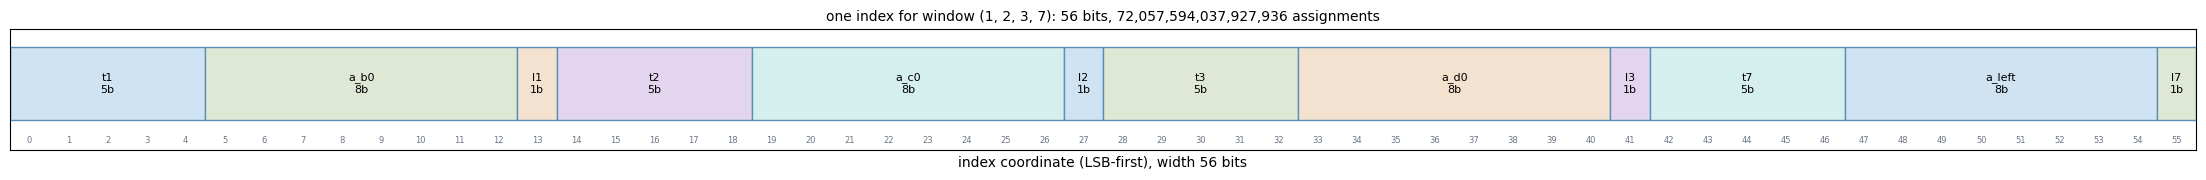

In [25]:
viz.show_index_layout(fields, query.n,
                      f"one index for window {window}: {query.n} bits, "
                      f"{1 << query.n:,} assignments")

**Seventy-two quadrillion assignments.** That is the space the query is defined
over. No algorithm here will enumerate it, and §9 measures how much of it is
actually touched.

## 8.2 The constraints, as an expression

Legality is written as a tree. `AllOf` means every child must hold, `AnyOf`
means at least one must, and each `Leaf` is an exact cover of one relation —
`t4 + 2 <= t7`, or `a_x + 8 <= a_y`, built by the same interval machinery as §4.

In [26]:
expression = query.expression()

viz.show_expression_tree(
    expression,
    f"acceptance expression for window {window}, target {(target_cycles, target_memory)}",
    max_depth=2,
)

acceptance expression for window (1, 2, 3, 7), target (8, 2)
total expression records: 4667
  AllOf 49 child(ren)  [every one must hold]
      Leaf  2 alternative(s)
      Leaf  1 alternative(s)
      Leaf  1 alternative(s)
      Leaf  2 alternative(s)
      Leaf  1 alternative(s)
      Leaf  1 alternative(s)
      Leaf  1 alternative(s)
      Leaf  1 alternative(s)
      Leaf  1 alternative(s)
      Leaf  1 alternative(s)
      Leaf  1 alternative(s)
      Leaf  1 alternative(s)
      Leaf  4 alternative(s)
      Leaf  4 alternative(s)
      Leaf  2 alternative(s)
      AnyOf 2 child(ren)  [at least one]
          Leaf  5 alternative(s)
          Leaf  1 alternative(s)
      AnyOf 2 child(ren)  [at least one]
          Leaf  62 alternative(s)
          Leaf  2 alternative(s)
      AnyOf 2 child(ren)  [at least one]
          Leaf  62 alternative(s)
          Leaf  2 alternative(s)
      AnyOf 2 child(ren)  [at least one]
          Leaf  5 alternative(s)
          Leaf  1 alternative(s

## 8.3 Asking

`si.solve` walks that tree depth-first, carrying **one current cube**. A
conjunction pushes its children in front, so each narrows the cube before the
next is touched. A leaf intersects the current cube with each alternative. When
the pending list empties, the surviving cube is *wholly inside* the acceptance
set — every index it denotes is a legal answer.

No product of constraint families is ever built.

In [27]:
result = si.solve(expression, query.n, meter=meter)

print("status  :", result.status)
print("visited :", f"{result.visited:,}", "cubes")
print("elapsed :", f"{result.elapsed:.3f}s")
print()
if result.is_sat:
    candidate_times, candidate_addresses = query.decode(result.cube)
    print("witness :", result.cube.label()[:60], "...")
elif result.is_unsat:
    print("UNSAT means: within this window, holding every other decision fixed,")
    print("no assignment meets that target. It says nothing about other windows,")
    print("and nothing about the program as a whole.")

status  :

 UNSAT
visited : 33,983 cubes
elapsed : 0.147s

UNSAT means: within this window, holding every other decision fixed,
no assignment meets that target. It says nothing about other windows,
and nothing about the program as a whole.


## 8.4 When the question is answered before it is asked

Some window and target pairs are refused during construction. If an operation
*outside* the window already issues at or past the target cycle, no choice inside
the window can help, and building the expression would be wasted work.

In [28]:
try:
    doomed = dk.JointQuery(
        facts, times, addresses, (1, 2, 3, 7), 7, 3,
        si.Budget(seconds=1.0).start(), dk.CoverCache(),
    )
    doomed.expression()
    print("constructed")
except dk.Infeasible as exc:
    print("Infeasible, raised while building:")
    print("   ", exc)

Infeasible, raised while building:
    external operation 10 issues at 7, at or past the target of 7


---

# 9. What the search does not do

This is the central efficiency claim, so it is stated with its denominator.

The query of §8 is defined over 2\*\*56 assignments. The search visited a few
tens of thousands of cubes. The ratio is the point.

In [29]:
probe = si.Budget(seconds=5.0, max_cover=4096, max_visited=50000,
                  max_records=20000).start()
probe_query = dk.JointQuery(facts, times, addresses, (1, 2, 3, 7), 8, 2,
                            probe, dk.CoverCache())
probe_expression = probe_query.expression()
construction_cost = probe.visited
probe_result = si.solve(probe_expression, probe_query.n, meter=probe)

domain = 1 << probe_query.n
print(f"index width                 : {probe_query.n} bits")
print(f"assignments in the domain   : {domain:,}")
print(f"cubes visited while building: {construction_cost:,}")
print(f"cubes visited in total      : {probe_result.visited:,}")
print(f"verdict                     : {probe_result.status}")
print()
print(f"one cube examined per {domain / probe_result.visited:,.0f} assignments")

index width                 : 56 bits
assignments in the domain   : 72,057,594,037,927,936
cubes visited while building: 20,050
cubes visited in total      : 33,983
verdict                     : UNSAT

one cube examined per 2,120,401,201,716 assignments


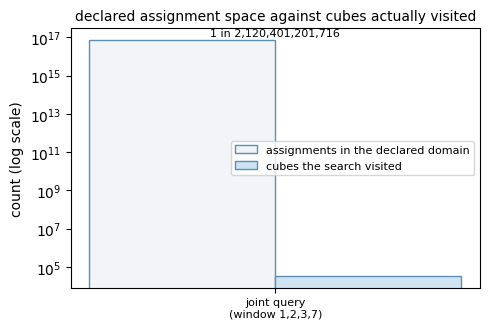

In [30]:
viz.show_search_economy(
    labels=["joint query\n(window 1,2,3,7)"],
    visited=[probe_result.visited],
    total=[domain],
    title="declared assignment space against cubes actually visited",
)

---

# 10. Three verdicts, and the one that matters

A query returns one of three things, and the distinction between the last two is
the most important safety property in the whole method:

| verdict | meaning |
|---|---|
| **SAT** | here is a cube of legal answers |
| **UNSAT** | the declared domain was **completely exhausted**; there is no answer |
| **UNKNOWN** | a declared budget ran out; **nothing was learned** |

`UNSAT` is a positive claim and it is only ever made after the search has
genuinely finished. `UNKNOWN` is not a weaker `UNSAT` — it is not a statement
about solutions at all. Reading one as the other would let a starved query
silently discard a legal improvement.

The cell below demonstrates it on **the same query**, changing nothing but the
budget. The cube cap is used rather than the clock so the result is
deterministic and reproduces on any machine.

In [31]:
print(f"construction alone costs {construction_cost:,} visits\n")
print(f"{'max_visited':>12}  {'verdict':<9} {'visited':>9}  reason")
for cap in (50000, 33000, 30000, 25000, 20000):
    starved = si.Budget(seconds=5.0, max_cover=4096, max_visited=cap,
                        max_records=20000).start()
    try:
        starved_query = dk.JointQuery(facts, times, addresses, (1, 2, 3, 7), 8, 2,
                                      starved, dk.CoverCache())
        starved_expression = starved_query.expression()
    except si.BudgetExhausted as exc:
        print(f"{cap:>12}  {'UNKNOWN':<9} {starved.visited:>9,}  "
              f"stopped while building: {exc.reason}")
        continue
    starved_result = si.solve(starved_expression, starved_query.n, meter=starved)
    print(f"{cap:>12}  {starved_result.status:<9} {starved_result.visited:>9,}  "
          f"{starved_result.reason or '-'}")

construction alone costs 20,050 visits

 max_visited  verdict     visited  reason
       50000  UNSAT        33,983  -


       33000  UNKNOWN      33,001  visited-cube budget exhausted


       30000  UNKNOWN      30,001  visited-cube budget exhausted
       25000  UNKNOWN      25,001  visited-cube budget exhausted
       20000  UNKNOWN      20,001  stopped while building: visited-cube budget exhausted


Read the first two rows together. With a cap of 50,000 the search finishes and
reports **UNSAT** after 33,983 cubes — a real answer. With a cap of 33,000 it
reports **UNKNOWN** after 33,001. Same program, same window, same target, same
expression. Only the budget moved.

If those two were conflated, the second row would claim that no improvement
exists in this window when in fact the search was simply stopped. The optimiser
therefore treats `UNKNOWN` as *"leave the incumbent exactly as it was"* and
never as evidence of anything.

---

# 11. What it actually achieves

Two measurements, reported together, because either one alone misleads.

The numbers below are read from the accepted comparison — 72 runs, three
repetitions of eight programs across three arms — rather than typed here.

In [32]:
evidence_path = (ROOT / "results/direct_index_v4_optimization_repair2"
                 / "comparison/runs.json")
evidence = json.loads(evidence_path.read_text())

print("evidence :", evidence_path.relative_to(ROOT))
print("arms     :", evidence["arms"])
print("runs     :", len(evidence["runs"]), "  repetitions:", evidence["repetitions"])
print("gates    :", "all passed" if evidence["gates"]["all_passed"]["passed"] else "FAILED")
print()
for arm in evidence["arms"]:
    summary = evidence["summary"][arm]
    print(f"{arm:14} combined score {summary['combined_score_mean']:.6f}   "
          f"median compile {summary['median_compile_seconds']:.6f}s")

evidence : results/direct_index_v4_optimization_repair2/comparison/runs.json
arms     : ['serial', 'classical', 'direct_index']
runs     : 72   repetitions: 3
gates    : all passed

serial         combined score 1.000000   median compile 0.000023s
classical      combined score 1.901379   median compile 0.000270s
direct_index   combined score 2.008466   median compile 0.174400s


In [33]:
rows = {(r["program"], r["arm"]): r for r in evidence["runs"] if r["repeat"] == 0}
names = evidence["program_names"]

better = equal = worse = 0
print(f"{'program':20} {'serial':>11} {'classical':>11} {'index':>11}   verdict")
for name in names:
    s, c, x = (rows[(name, a)] for a in ("serial", "classical", "direct_index"))
    pc, px = c["cycles"] * c["scratch"], x["cycles"] * x["scratch"]
    verdict = "better" if px < pc else ("equal" if px == pc else "WORSE")
    better += verdict == "better"; equal += verdict == "equal"; worse += verdict == "WORSE"
    print(f"{name:20} {s['cycles']:>4}x{s['scratch']:<6} {c['cycles']:>4}x{c['scratch']:<6} "
          f"{x['cycles']:>4}x{x['scratch']:<6}   {verdict}")

print()
print(f"against the greedy baseline over {len(names)} programs: "
      f"{better} better, {equal} equal, {worse} worse")

program                   serial   classical       index   verdict
scalar_pipeline        18x15       14x6        14x6        equal
scalar_dual_chain      12x9         9x5         8x3        better
vector_axpy            14x73       10x32       10x24       better
vector_bitmix          16x89       10x40       10x40       equal
mixed_broadcast        11x42        9x17       10x24       WORSE
parallel_memory        21x128      14x56       13x40       better
scalar_selects         20x16        9x6         9x6        equal
vector_reduction       19x137      12x40       12x40       equal

against the greedy baseline over 8 programs: 3 better, 4 equal, 1 worse


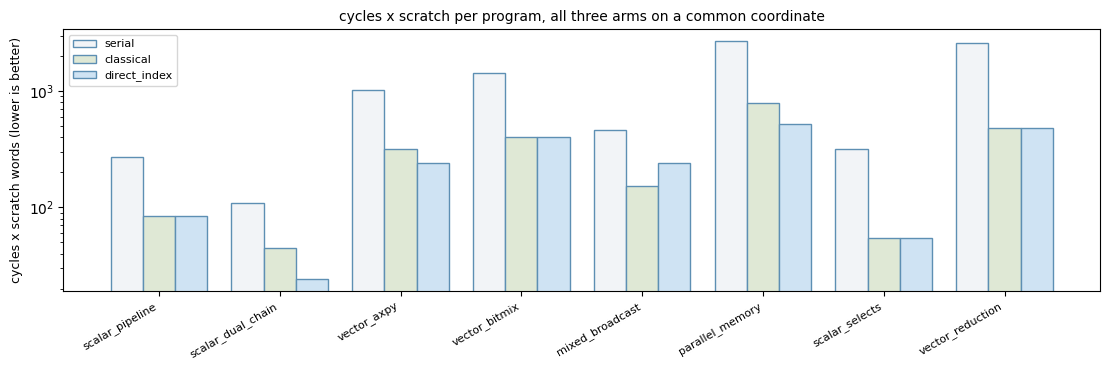

In [34]:
viz.show_program_results(
    names,
    {arm: [rows[(n, arm)]["cycles"] * rows[(n, arm)]["scratch"] for n in names]
     for arm in ("serial", "classical", "direct_index")},
    "cycles x scratch per program, all three arms on a common coordinate",
)

In [35]:
import statistics as stats

classical_compile = stats.median(
    r["compile_seconds"] for r in evidence["runs"] if r["arm"] == "classical")
direct_compile = stats.median(
    r["compile_seconds"] for r in evidence["runs"] if r["arm"] == "direct_index")

direct_score = evidence["summary"]["direct_index"]["combined_score_mean"]
classical_score = evidence["summary"]["classical"]["combined_score_mean"]

print(f"combined score   : {direct_score:.4f} against {classical_score:.4f}"
      f"   ({100 * (direct_score / classical_score - 1):+.2f}%)")
print(f"median compile   : {direct_compile:.6f}s against {classical_compile:.6f}s")
print(f"                   {direct_compile / classical_compile:,.0f} times slower")
print()
print("Both halves of that sentence are the result. A 5.6% better score, bought")
print(f"at roughly {direct_compile / classical_compile:,.0f}x the compile time, is")
print("what this method currently is on this benchmark.")

combined score   : 2.0085 against 1.9014   (+5.63%)
median compile   : 0.174400s against 0.000270s
                   646 times slower

Both halves of that sentence are the result. A 5.6% better score, bought
at roughly 646x the compile time, is
what this method currently is on this benchmark.


## 11.1 The program it loses on

`mixed_broadcast` is the one program where the greedy baseline wins: 9 cycles
and 17 words against 10 and 24. Reporting the three wins without this would be
reporting a selection, not a result.

In [36]:
loser = "mixed_broadcast"
c, x = rows[(loser, "classical")], rows[(loser, "direct_index")]
print(f"{loser}")
print(f"   classical : {c['cycles']} cycles x {c['scratch']} words = {c['cycles'] * c['scratch']}")
print(f"   index     : {x['cycles']} cycles x {x['scratch']} words = {x['cycles'] * x['scratch']}")
print(f"   the index method is worse by a factor of "
      f"{(x['cycles'] * x['scratch']) / (c['cycles'] * c['scratch']):.2f}")

mixed_broadcast
   classical : 9 cycles x 17 words = 153
   index     : 10 cycles x 24 words = 240
   the index method is worse by a factor of 1.57


## 11.2 The optimiser contributes nothing here

§8 built an elaborate machine for asking many decisions at once. On the eight
public programs it accepts **not one improvement**. Every result in the table
above is the bootstrap of §5 to §7.

This is measured below rather than asserted, and it matches the lead review,
which records the same thing: the optimiser is *"useful on some generated
programs despite adding no public-score gain."*

In [37]:
print(f"{'program':22} {'bootstrap':>10} {'final':>10} {'queries':>8} "
      f"{'SAT':>4} {'UNSAT':>6} {'UNKNOWN':>8} {'accepted':>9}")

total_queries = total_sat = total_accepted = 0
for path in sorted((ROOT / ".reference/programs").glob("*.json")):
    each = machine.load_program(path)
    _, each_report = dcomp.compile_with_report(each)
    boot, opt = each_report["bootstrap"], each_report["optimisation"]
    status = opt["statuses"]
    unknown = status["UNKNOWN_SEARCH"] + status["UNKNOWN_CONSTRUCTION"]
    total_queries += opt["attempted_queries"]
    total_sat += status["SAT"]
    total_accepted += opt["accepted"]
    print(f"{path.stem:22} {boot['cycles']:>4}x{boot['footprint']:<5} "
          f"{each_report['cycles']:>4}x{each_report['footprint']:<5} "
          f"{opt['attempted_queries']:>8} {status['SAT']:>4} {status['UNSAT']:>6} "
          f"{unknown:>8} {opt['accepted']:>9}")

print()
print(f"over all 8 programs: {total_queries} joint queries attempted, "
      f"{total_sat} satisfiable, {total_accepted} accepted")

program                 bootstrap      final  queries  SAT  UNSAT  UNKNOWN  accepted


01_scalar_pipeline       14x6       14x6           18    0      0        2         0


02_scalar_dual_chain      8x3        8x3           24    0      5        0         0


03_vector_axpy           10x24      10x24          28    0      4        2         0


04_vector_bitmix         10x40      10x40          32    0      4        4         0


05_mixed_broadcast       10x24      10x24          20    0      5        5         0
06_parallel_memory       13x40      13x40          32    0      3        4         0


07_scalar_selects         9x6        9x6           32    0      3        5         0
08_vector_reduction      12x40      12x40          32    0      3        4         0

over all 8 programs: 218 joint queries attempted, 0 satisfiable, 0 accepted


---

# 12. What to take away, and what to try

**The idea.** A compiler decision is a member of a set. Write the set down as
cubes, combine sets with integer operations, and read the answer off the result.
No priority rule, no first-fit scan, no backtracking.

**What it buys.** Exactness. A cover is never an approximation of the legal set,
so a query that returns `UNSAT` has genuinely exhausted its domain, and a
`SAT` witness is legal by construction — then validated again anyway, twice,
before anything is kept.

**What it costs.** 646 times the baseline's compile time for a 5.6%
better score, and a method whose joint-query half earns nothing at all on this
particular benchmark. Both belong in any honest description of it.

**Where it is weakest.** The one program it loses on, `mixed_broadcast`, is not
explained by anything above. The bootstrap's greedy-smallest choice is locally
right and globally wrong there, and the joint query never finds the repair.

## Exercises

1. In §2, change `free_mask` to `0b0110` and predict the members before running
   it. Which coordinates carry which weights?
2. In §4.1, widen the interval to `si.interval(cycle_field, 0, 14, 4)`. How many
   cubes? Now try `0, 15`. Why does the second collapse to one?
3. In §5, edit `blocked` to `[0, 1]` and re-run the four steps. Which cycle is
   chosen, and how many cubes does the legal set need?
4. In §10, find the cap that first turns `UNSAT` into `UNKNOWN` to within 100
   cubes. What does its exact position tell you about the search order?
5. In §11.1, compile `05_mixed_broadcast.json` with `optimise=False` and then
   with `optimise=True`. Confirm they agree, then read `report["optimisation"]`
   to see which targets were tried and why each was refused.